# Step 10 - Modification on 3 features & preprocessing for prediction

## 1. Convert 'population' to 'population_density'

import useful packages

In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
from shapely import wkt

import datasets

In [2]:
merged_data = pd.read_csv('../data/curated/merged_data/merged_data_with_facility.csv')
sa2_info = pd.read_csv('../data/curated/external_data/sa2_info.csv')
sa2_population = pd.read_csv('../data/raw/external_data/vic_popdata.csv')

data overview

In [3]:
merged_data.head()

,name,rental_price,num_bedroom,num_bathroom,num_parking,postcode,coordinates,property_geometry,sa2_code,sa2_name,...,closest_hospital,hospital_distance(KM),closest_mall,mall_distance(KM),closest_park,park_distance(KM),closest_station,station_distance(KM),closest_distance_station(KM),CBD_distance(KM)
0,31 Chittagong Drive Clyde North VIC 3978,575.0,4,2,2.0,3978.0,"[-38.1053122, 145.3570863]",POINT (145.3570863 -38.1053122),212031556.0,Clyde North - South,...,"[-38.045325, 145.347181]",6.726397,"[-38.1184718, 145.3213262]",3.453903,"[-38.13958090963712, 145.36252669303045]",3.840116,"['[-38.05104856543076, 145.3665303282505]', '[...",6.090210,11.8866,97.390646
1,50 Elmtree Crescent Clyde North VIC 3978,560.0,4,2,2.0,3978.0,"[-38.0825712, 145.3561984]",POINT (145.3561984 -38.0825712),212031555.0,Clyde North - North,...,"[-38.045325, 145.347181]",4.216162,"[-38.0604189, 145.3394612]",2.866025,"[-38.03401014838179, 145.37166338662394]",5.566924,"['[-38.05104856543076, 145.3665303282505]', '[...",3.619981,5.3735,95.567693
2,7 Mortdale Lane Clyde North VIC 3978,490.0,2,2,1.0,3978.0,"[-38.0961758, 145.3800644]",POINT (145.3800644 -38.0961758),212031556.0,Clyde North - South,...,"[-38.045325, 145.347181]",6.344909,"[-38.0604189, 145.3394612]",5.332842,"[-38.13958090963712, 145.36252669303045]",5.064419,"['[-38.0663192834778, 145.4116572812351]', '[-...",4.320648,8.9170,98.122824
3,54 Walhallow Drive Clyde North VIC 3978,540.0,4,2,1.0,3978.0,"[-38.1133324, 145.3457396]",POINT (145.3457396 -38.1133324),212031556.0,Clyde North - South,...,"[-38.113312, 145.280832]",5.678594,"[-38.1184718, 145.3213262]",2.210922,"[-38.13958090963712, 145.36252669303045]",3.267265,"['[-38.0995872148084, 145.2804738077291]', '[-...",5.911467,8.1066,97.325206
4,10 Sicily Road Clyde North VIC 3978,520.0,4,2,2.0,3978.0,"[-38.1295789, 145.3642993]",POINT (145.3642993 -38.1295789),212031303.0,Cranbourne South,...,"[-38.113312, 145.280832]",7.522231,"[-38.1184718, 145.3213262]",3.956745,"[-38.13958090963712, 145.36252669303045]",1.122928,"['[-38.0995872148084, 145.2804738077291]', '[-...",8.056215,10.1328,99.752000


merge sa2 population & sa2 info together

In [4]:
sa2_population = sa2_population \
    .merge(
        sa2_info[['sa2_code', 'sa2_name', 'sa2_geometry']], 
        left_on = 'SA2_NAME', 
        right_on = 'sa2_name', 
        how = 'left'
    ).drop('SA2_NAME', axis=1)

In [5]:
sa2_population.head()

,Unnamed: 0,2001,2002,2003,2004,2005,2006,2007,2008,2009,...,2015,2016,2017,2018,2019,2020,2021,sa2_code,sa2_name,sa2_geometry
0,0,5756,6092,6293,6480,6648,6761,7034,7272,7614,...,11039,11852,12649,13537,14434,15507,16841,201011001,Alfredton,POLYGON ((143.78282104711133 -37.5666578080732...
1,1,11497,11708,12015,12189,12269,12356,12408,12480,12476,...,12300,12301,12266,12244,12320,12196,12071,201011002,Ballarat,POLYGON ((143.81896375194268 -37.5558184903035...
2,2,5320,5399,5557,5620,5857,6037,6131,6252,6431,...,7191,7311,7409,7418,7458,7377,7229,201011005,Buninyong,POLYGON ((143.8417079819547 -37.61596158212406...
3,3,4154,4225,4371,4465,4704,5041,5206,5349,5557,...,6846,7195,7622,8183,8890,9755,10648,201011006,Delacombe,POLYGON ((143.7505006002539 -37.59119089617515...
4,4,3317,3378,3411,3473,3508,3542,3594,3658,3714,...,3966,3990,4004,4042,4112,4152,4211,201011007,Smythes Creek,POLYGON ((143.7329551500814 -37.62333175526272...


Convert the pd df to gpd df

In [6]:
# Convert string representations of geometries to actual geometry objects
sa2_population['geometry'] = sa2_population['sa2_geometry'].apply(wkt.loads)

# Create a GeoDataFrame
sa2_population_gdf = gpd.GeoDataFrame(sa2_population, geometry='geometry')

In [7]:
sa2_population_gdf.head()

,Unnamed: 0,2001,2002,2003,2004,2005,2006,2007,2008,2009,...,2016,2017,2018,2019,2020,2021,sa2_code,sa2_name,sa2_geometry,geometry
0,0,5756,6092,6293,6480,6648,6761,7034,7272,7614,...,11852,12649,13537,14434,15507,16841,201011001,Alfredton,POLYGON ((143.78282104711133 -37.5666578080732...,"POLYGON ((143.78282 -37.56666, 143.75558 -37.5..."
1,1,11497,11708,12015,12189,12269,12356,12408,12480,12476,...,12301,12266,12244,12320,12196,12071,201011002,Ballarat,POLYGON ((143.81896375194268 -37.5558184903035...,"POLYGON ((143.81896 -37.55582, 143.81644 -37.5..."
2,2,5320,5399,5557,5620,5857,6037,6131,6252,6431,...,7311,7409,7418,7458,7377,7229,201011005,Buninyong,POLYGON ((143.8417079819547 -37.61596158212406...,"POLYGON ((143.84171 -37.61596, 143.84176 -37.6..."
3,3,4154,4225,4371,4465,4704,5041,5206,5349,5557,...,7195,7622,8183,8890,9755,10648,201011006,Delacombe,POLYGON ((143.7505006002539 -37.59119089617515...,"POLYGON ((143.75050 -37.59119, 143.75044 -37.5..."
4,4,3317,3378,3411,3473,3508,3542,3594,3658,3714,...,3990,4004,4042,4112,4152,4211,201011007,Smythes Creek,POLYGON ((143.7329551500814 -37.62333175526272...,"POLYGON ((143.73296 -37.62333, 143.73263 -37.6..."


Assign 1 to the sa2 which has the original (2001) population with 0. This is to avoid the appearance of inf in 'pop_density'

In [8]:
rows_with_inf = sa2_population_gdf[sa2_population_gdf['sa2_code'] == 210051542.0]
rows_with_inf

,Unnamed: 0,2001,2002,2003,2004,2005,2006,2007,2008,2009,...,2016,2017,2018,2019,2020,2021,sa2_code,sa2_name,sa2_geometry,geometry
294,294,0,0,0,0,0,0,11,36,89,...,5754,6691,7482,8326,9253,9975,210051542,Craigieburn - North West,POLYGON ((144.89459802520648 -37.5665004012005...,"POLYGON ((144.89460 -37.56650, 144.89485 -37.5..."


In [9]:
cols_to_replace = []

for year in range(2001, 2022): 
    year = str(year)
    cols_to_replace.append(year)

In [10]:
cols_to_replace

['2001',
 '2002',
 '2003',
 '2004',
 '2005',
 '2006',
 '2007',
 '2008',
 '2009',
 '2010',
 '2011',
 '2012',
 '2013',
 '2014',
 '2015',
 '2016',
 '2017',
 '2018',
 '2019',
 '2020',
 '2021']

In [11]:
sa2_population_gdf[cols_to_replace] = sa2_population_gdf[cols_to_replace].replace(0, 1)

In [12]:
rows_with_inf = sa2_population_gdf[sa2_population_gdf['sa2_code'] == 210051542.0]
rows_with_inf

,Unnamed: 0,2001,2002,2003,2004,2005,2006,2007,2008,2009,...,2016,2017,2018,2019,2020,2021,sa2_code,sa2_name,sa2_geometry,geometry
294,294,1,1,1,1,1,1,11,36,89,...,5754,6691,7482,8326,9253,9975,210051542,Craigieburn - North West,POLYGON ((144.89459802520648 -37.5665004012005...,"POLYGON ((144.89460 -37.56650, 144.89485 -37.5..."


Calculate 'population density' using 'population' & sa2 geometry

In [13]:
# set beginning CRS. Original data is WGS84 coordinate system (EPSG:4326).
sa2_population_gdf.crs = "EPSG:4326"

# change data to a projection using meter. Here we use EPSG:3857, which is Web Mercator projection.
sa2_population_gdf = sa2_population_gdf.to_crs("EPSG:3857")

# calculate area with new CRS, then result from square meter change to square kilometer.
sa2_population_gdf['area(km2)'] = sa2_population_gdf['geometry'].area / 1e6

# use square kilometer area to find population density.
year_list = range(2001, 2022)

for year in year_list:
    feature_name = f'{year}_pop_density'
    year = f'{year}'

    sa2_population_gdf[feature_name] = sa2_population_gdf[year] / sa2_population_gdf['area(km2)']
    sa2_population_gdf.drop(columns=[year], inplace=True)

In [14]:
sa2_population_gdf

,Unnamed: 0,sa2_code,sa2_name,sa2_geometry,geometry,area(km2),2001_pop_density,2002_pop_density,2003_pop_density,2004_pop_density,...,2012_pop_density,2013_pop_density,2014_pop_density,2015_pop_density,2016_pop_density,2017_pop_density,2018_pop_density,2019_pop_density,2020_pop_density,2021_pop_density
0,0,201011001,Alfredton,POLYGON ((143.78282104711133 -37.5666578080732...,"POLYGON ((16005830.424 -4518388.673, 16002797....",83.986696,68.534664,72.535298,74.928534,77.155077,...,107.874228,115.661176,123.090924,131.437484,141.117589,150.607187,161.180290,171.860553,184.636386,200.519854
1,1,201011002,Ballarat,POLYGON ((143.81896375194268 -37.5558184903035...,"POLYGON ((16009853.811 -4516866.503, 16009573....",19.731136,582.683136,593.376895,608.936060,617.754610,...,626.269072,626.015665,624.748632,623.380236,623.430918,621.657071,620.542082,624.393863,618.109379,611.774214
2,2,201011005,Buninyong,POLYGON ((143.8417079819547 -37.61596158212406...,"POLYGON ((16012385.687 -4525315.218, 16012390....",82.416911,64.549859,65.508401,67.425483,68.189889,...,83.162544,84.739891,85.928967,87.251511,88.707523,89.896599,90.005800,90.491137,89.508329,87.712581
3,3,201011006,Delacombe,POLYGON ((143.7505006002539 -37.59119089617515...,"POLYGON ((16002232.528 -4521834.682, 16002226....",54.488687,76.236008,77.539031,80.218486,81.943615,...,110.481649,115.014700,120.814069,125.640759,132.045758,139.882247,150.177962,163.153132,179.027987,195.416710
4,4,201011007,Smythes Creek,POLYGON ((143.7329551500814 -37.62333175526272...,"POLYGON ((16000279.378 -4526351.027, 16000243....",167.215415,19.836688,20.201487,20.398837,20.769616,...,23.155760,23.406933,23.592323,23.717909,23.861436,23.945161,24.172413,24.591034,24.830247,25.183085
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
517,517,217031476,Otway,MULTIPOLYGON (((143.40263218222083 -38.7815167...,"MULTIPOLYGON (((15963507.993 -4690423.867, 159...",2472.129694,1.396367,1.407289,1.420233,1.420233,...,1.397985,1.414570,1.423469,1.431155,1.438436,1.470392,1.500730,1.537945,1.582037,1.609543
518,518,217041477,Moyne - East,POLYGON ((142.41438437646818 -38.0930256782602...,"POLYGON ((15853496.750 -4592575.569, 15853453....",5297.674845,1.268103,1.265461,1.260175,1.253946,...,1.276787,1.273955,1.271124,1.267726,1.266405,1.267915,1.273389,1.283204,1.299249,1.319447
519,519,217041478,Moyne - West,MULTIPOLYGON (((142.00870118938005 -38.4171452...,"MULTIPOLYGON (((15808336.305 -4638523.206, 158...",3301.017868,2.519526,2.540731,2.559816,2.571025,...,2.777022,2.817313,2.842457,2.867903,2.909103,2.934246,2.963631,2.982413,2.986655,3.019372
520,520,217041479,Warrnambool - North,POLYGON ((142.4366836580644 -38.35544112113083...,"POLYGON ((15855979.095 -4629760.124, 15855967....",101.634842,167.786949,171.683251,174.408694,176.484754,...,199.272215,202.804468,205.933316,208.757151,210.970959,213.391389,216.008601,218.271605,220.554286,221.085600


To get the population density rate, we use:
$$r = \left( \left( 1 + G \right)^{\frac{1}{t}} \right) - 1$$
Where:
- $r$: Compound Annual Growth Rate (CAGR)
- $G$: Total growth rate over the time period (expressed as a decimal, e.g., 0.20 for 20%)
- $t$: Number of years

In [15]:
pop_density_difference = sa2_population_gdf['2021_pop_density'] - sa2_population_gdf['2001_pop_density']
sa2_population_gdf['growth_rate(%)'] = (pop_density_difference / sa2_population_gdf['2001_pop_density']) * 100

In [16]:
sa2_population_gdf.head()

,Unnamed: 0,sa2_code,sa2_name,sa2_geometry,geometry,area(km2),2001_pop_density,2002_pop_density,2003_pop_density,2004_pop_density,...,2013_pop_density,2014_pop_density,2015_pop_density,2016_pop_density,2017_pop_density,2018_pop_density,2019_pop_density,2020_pop_density,2021_pop_density,growth_rate(%)
0,0,201011001,Alfredton,POLYGON ((143.78282104711133 -37.5666578080732...,"POLYGON ((16005830.424 -4518388.673, 16002797....",83.986696,68.534664,72.535298,74.928534,77.155077,...,115.661176,123.090924,131.437484,141.117589,150.607187,161.180290,171.860553,184.636386,200.519854,192.581654
1,1,201011002,Ballarat,POLYGON ((143.81896375194268 -37.5558184903035...,"POLYGON ((16009853.811 -4516866.503, 16009573....",19.731136,582.683136,593.376895,608.936060,617.754610,...,626.015665,624.748632,623.380236,623.430918,621.657071,620.542082,624.393863,618.109379,611.774214,4.992607
2,2,201011005,Buninyong,POLYGON ((143.8417079819547 -37.61596158212406...,"POLYGON ((16012385.687 -4525315.218, 16012390....",82.416911,64.549859,65.508401,67.425483,68.189889,...,84.739891,85.928967,87.251511,88.707523,89.896599,90.005800,90.491137,89.508329,87.712581,35.883459
3,3,201011006,Delacombe,POLYGON ((143.7505006002539 -37.59119089617515...,"POLYGON ((16002232.528 -4521834.682, 16002226....",54.488687,76.236008,77.539031,80.218486,81.943615,...,115.014700,120.814069,125.640759,132.045758,139.882247,150.177962,163.153132,179.027987,195.416710,156.331247
4,4,201011007,Smythes Creek,POLYGON ((143.7329551500814 -37.62333175526272...,"POLYGON ((16000279.378 -4526351.027, 16000243....",167.215415,19.836688,20.201487,20.398837,20.769616,...,23.406933,23.592323,23.717909,23.861436,23.945161,24.172413,24.591034,24.830247,25.183085,26.952065


In [17]:
t = 20
G = sa2_population_gdf['growth_rate(%)']

In [18]:
r = (pow((1 + G/100), 1/t) - 1) * 100
sa2_population_gdf['annual_growth_rate(%)'] = r

In [19]:
sa2_population_gdf.head()

,Unnamed: 0,sa2_code,sa2_name,sa2_geometry,geometry,area(km2),2001_pop_density,2002_pop_density,2003_pop_density,2004_pop_density,...,2014_pop_density,2015_pop_density,2016_pop_density,2017_pop_density,2018_pop_density,2019_pop_density,2020_pop_density,2021_pop_density,growth_rate(%),annual_growth_rate(%)
0,0,201011001,Alfredton,POLYGON ((143.78282104711133 -37.5666578080732...,"POLYGON ((16005830.424 -4518388.673, 16002797....",83.986696,68.534664,72.535298,74.928534,77.155077,...,123.090924,131.437484,141.117589,150.607187,161.180290,171.860553,184.636386,200.519854,192.581654,5.514551
1,1,201011002,Ballarat,POLYGON ((143.81896375194268 -37.5558184903035...,"POLYGON ((16009853.811 -4516866.503, 16009573....",19.731136,582.683136,593.376895,608.936060,617.754610,...,624.748632,623.380236,623.430918,621.657071,620.542082,624.393863,618.109379,611.774214,4.992607,0.243896
2,2,201011005,Buninyong,POLYGON ((143.8417079819547 -37.61596158212406...,"POLYGON ((16012385.687 -4525315.218, 16012390....",82.416911,64.549859,65.508401,67.425483,68.189889,...,85.928967,87.251511,88.707523,89.896599,90.005800,90.491137,89.508329,87.712581,35.883459,1.544950
3,3,201011006,Delacombe,POLYGON ((143.7505006002539 -37.59119089617515...,"POLYGON ((16002232.528 -4521834.682, 16002226....",54.488687,76.236008,77.539031,80.218486,81.943615,...,120.814069,125.640759,132.045758,139.882247,150.177962,163.153132,179.027987,195.416710,156.331247,4.819016
4,4,201011007,Smythes Creek,POLYGON ((143.7329551500814 -37.62333175526272...,"POLYGON ((16000279.378 -4526351.027, 16000243....",167.215415,19.836688,20.201487,20.398837,20.769616,...,23.592323,23.717909,23.861436,23.945161,24.172413,24.591034,24.830247,25.183085,26.952065,1.200344


check the instance which exists the growth_rate with inf before

In [20]:
rows_with_inf = sa2_population_gdf[sa2_population_gdf['sa2_code'] == 210051542.0]
rows_with_inf

,Unnamed: 0,sa2_code,sa2_name,sa2_geometry,geometry,area(km2),2001_pop_density,2002_pop_density,2003_pop_density,2004_pop_density,...,2014_pop_density,2015_pop_density,2016_pop_density,2017_pop_density,2018_pop_density,2019_pop_density,2020_pop_density,2021_pop_density,growth_rate(%),annual_growth_rate(%)
294,294,210051542,Craigieburn - North West,POLYGON ((144.89459802520648 -37.5665004012005...,"POLYGON ((16129592.871 -4518366.566, 16129621....",3.060914,0.3267,0.3267,0.3267,0.3267,...,1001.988416,1384.227231,1879.830891,2185.948643,2444.368218,2720.102885,3022.953639,3258.830925,997400.0,58.469485


Calculate '2023 population density'

In [21]:
sa2_population_gdf['2023_pop_density'] = sa2_population_gdf['2021_pop_density'] * (1 + sa2_population_gdf['annual_growth_rate(%)'] / 100)**2

In [22]:
sa2_population_gdf.head()

,Unnamed: 0,sa2_code,sa2_name,sa2_geometry,geometry,area(km2),2001_pop_density,2002_pop_density,2003_pop_density,2004_pop_density,...,2015_pop_density,2016_pop_density,2017_pop_density,2018_pop_density,2019_pop_density,2020_pop_density,2021_pop_density,growth_rate(%),annual_growth_rate(%),2023_pop_density
0,0,201011001,Alfredton,POLYGON ((143.78282104711133 -37.5666578080732...,"POLYGON ((16005830.424 -4518388.673, 16002797....",83.986696,68.534664,72.535298,74.928534,77.155077,...,131.437484,141.117589,150.607187,161.180290,171.860553,184.636386,200.519854,192.581654,5.514551,223.245179
1,1,201011002,Ballarat,POLYGON ((143.81896375194268 -37.5558184903035...,"POLYGON ((16009853.811 -4516866.503, 16009573....",19.731136,582.683136,593.376895,608.936060,617.754610,...,623.380236,623.430918,621.657071,620.542082,624.393863,618.109379,611.774214,4.992607,0.243896,614.762035
2,2,201011005,Buninyong,POLYGON ((143.8417079819547 -37.61596158212406...,"POLYGON ((16012385.687 -4525315.218, 16012390....",82.416911,64.549859,65.508401,67.425483,68.189889,...,87.251511,88.707523,89.896599,90.005800,90.491137,89.508329,87.712581,35.883459,1.544950,90.443748
3,3,201011006,Delacombe,POLYGON ((143.7505006002539 -37.59119089617515...,"POLYGON ((16002232.528 -4521834.682, 16002226....",54.488687,76.236008,77.539031,80.218486,81.943615,...,125.640759,132.045758,139.882247,150.177962,163.153132,179.027987,195.416710,156.331247,4.819016,214.704849
4,4,201011007,Smythes Creek,POLYGON ((143.7329551500814 -37.62333175526272...,"POLYGON ((16000279.378 -4526351.027, 16000243....",167.215415,19.836688,20.201487,20.398837,20.769616,...,23.717909,23.861436,23.945161,24.172413,24.591034,24.830247,25.183085,26.952065,1.200344,25.791281


select the useful features

In [23]:
useful_feature_list = ['sa2_code', 'sa2_name', '2023_pop_density', 'annual_growth_rate(%)']
sa2_population_density = sa2_population_gdf[useful_feature_list]
sa2_population_density.rename(columns={'annual_growth_rate(%)': 'annual_pop_density_growth_rate(%)'}, inplace=True)

/tmp/ipykernel_8008/460432487.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sa2_population_density.rename(columns={'annual_growth_rate(%)': 'annual_pop_density_growth_rate(%)'}, inplace=True)


In [24]:
sa2_population_density

,sa2_code,sa2_name,2023_pop_density,annual_pop_density_growth_rate(%)
0,201011001,Alfredton,223.245179,5.514551
1,201011002,Ballarat,614.762035,0.243896
2,201011005,Buninyong,90.443748,1.544950
3,201011006,Delacombe,214.704849,4.819016
4,201011007,Smythes Creek,25.791281,1.200344
...,...,...,...,...
517,217031476,Otway,1.632574,0.712913
518,217041477,Moyne - East,1.324694,0.198647
519,217041478,Moyne - West,3.074513,0.908997
520,217041479,Warrnambool - North,227.269253,1.388831


overwirte 2 features about 'population' in the original merged_data

In [25]:
merged_data = merged_data.merge(sa2_population_density[['sa2_code', '2023_pop_density', 'annual_pop_density_growth_rate(%)']], on = 'sa2_code', how = 'left')
merged_data.drop(columns=['2021_population', 'avg_pop_growth_rates(%)'], inplace=True)

In [26]:
merged_data

,name,rental_price,num_bedroom,num_bathroom,num_parking,postcode,coordinates,property_geometry,sa2_code,sa2_name,...,closest_mall,mall_distance(KM),closest_park,park_distance(KM),closest_station,station_distance(KM),closest_distance_station(KM),CBD_distance(KM),2023_pop_density,annual_pop_density_growth_rate(%)
0,31 Chittagong Drive Clyde North VIC 3978,575.0,4,2,2.0,3978.0,"[-38.1053122, 145.3570863]",POINT (145.3570863 -38.1053122),212031556.0,Clyde North - South,...,"[-38.1184718, 145.3213262]",3.453903,"[-38.13958090963712, 145.36252669303045]",3.840116,"['[-38.05104856543076, 145.3665303282505]', '[...",6.090210,11.8866,97.390646,965.216952,42.856643
1,50 Elmtree Crescent Clyde North VIC 3978,560.0,4,2,2.0,3978.0,"[-38.0825712, 145.3561984]",POINT (145.3561984 -38.0825712),212031555.0,Clyde North - North,...,"[-38.0604189, 145.3394612]",2.866025,"[-38.03401014838179, 145.37166338662394]",5.566924,"['[-38.05104856543076, 145.3665303282505]', '[...",3.619981,5.3735,95.567693,1746.760558,35.089903
2,7 Mortdale Lane Clyde North VIC 3978,490.0,2,2,1.0,3978.0,"[-38.0961758, 145.3800644]",POINT (145.3800644 -38.0961758),212031556.0,Clyde North - South,...,"[-38.0604189, 145.3394612]",5.332842,"[-38.13958090963712, 145.36252669303045]",5.064419,"['[-38.0663192834778, 145.4116572812351]', '[-...",4.320648,8.9170,98.122824,965.216952,42.856643
3,54 Walhallow Drive Clyde North VIC 3978,540.0,4,2,1.0,3978.0,"[-38.1133324, 145.3457396]",POINT (145.3457396 -38.1133324),212031556.0,Clyde North - South,...,"[-38.1184718, 145.3213262]",2.210922,"[-38.13958090963712, 145.36252669303045]",3.267265,"['[-38.0995872148084, 145.2804738077291]', '[-...",5.911467,8.1066,97.325206,965.216952,42.856643
4,10 Sicily Road Clyde North VIC 3978,520.0,4,2,2.0,3978.0,"[-38.1295789, 145.3642993]",POINT (145.3642993 -38.1295789),212031303.0,Cranbourne South,...,"[-38.1184718, 145.3213262]",3.956745,"[-38.13958090963712, 145.36252669303045]",1.122928,"['[-38.0995872148084, 145.2804738077291]', '[-...",8.056215,10.1328,99.752000,151.921192,6.726716
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8797,61 Tongue Street Yarraville VIC 3013,630.0,2,1,0.0,3013.0,"[-37.8131463, 144.8909053]",POINT (144.8909053 -37.8131463),213031352.0,Yarraville,...,"[-37.8016476, 144.8977057]",1.411290,"[-37.83084513979606, 144.91345002848863]",2.791844,"['[-37.81567190405462, 144.89006145414797]', '...",0.290453,1.1480,45.903694,1773.237842,1.100932
8798,47 Mill Avenue Yarraville VIC 3013,730.0,4,3,2.0,3013.0,"[-37.8222822, 144.872198]",POINT (144.872198 -37.8222822),213031352.0,Yarraville,...,"[-37.828989, 144.84627]",2.396280,"[-37.83084513979606, 144.91345002848863]",3.746179,"['[-37.83072411396968, 144.88584876958876]', '...",1.522703,2.1264,45.752205,1773.237842,1.100932
8799,12 Adeney Street Yarraville VIC 3013,450.0,3,1,2.0,3013.0,"[-37.8163817, 144.8666543]",POINT (144.8666543 -37.8163817),213031352.0,Yarraville,...,"[-37.828989, 144.84627]",2.273966,"[-37.83084513979606, 144.91345002848863]",4.413664,"['[-37.7993395010312, 144.86344949623717]', '[...",1.915810,2.8147,44.935453,1773.237842,1.100932
8800,229B Somerville Road Yarraville VIC 3013,300.0,1,1,0.0,3013.0,"[-37.8124289, 144.8779569]",POINT (144.8779569 -37.8124289),213031352.0,Yarraville,...,"[-37.8016476, 144.8977057]",2.108881,"[-37.83084513979606, 144.91345002848863]",3.729966,"['[-37.81567190405462, 144.89006145414797]', '...",1.122803,1.8488,45.157145,1773.237842,1.100932


store `sa2_population_density.csv`

In [27]:
output_directory = '../data/curated/external_data/sa2_population_density.csv'
sa2_population_density.to_csv(output_directory, index=False)

## 2. Calculate "2023 personal income"

In [28]:
merged_data['2021_personal_income'] = merged_data['personal_income']
merged_data.drop(columns=['personal_income'], inplace=True)

In [29]:
merged_data['2023_personal_income'] = merged_data['2021_personal_income'] * (1 + merged_data['avg_income_growth_rate(%)'] / 100)**2
merged_data.drop(columns=['2021_personal_income'], inplace=True)

In [30]:
merged_data

,name,rental_price,num_bedroom,num_bathroom,num_parking,postcode,coordinates,property_geometry,sa2_code,sa2_name,...,mall_distance(KM),closest_park,park_distance(KM),closest_station,station_distance(KM),closest_distance_station(KM),CBD_distance(KM),2023_pop_density,annual_pop_density_growth_rate(%),2023_personal_income
0,31 Chittagong Drive Clyde North VIC 3978,575.0,4,2,2.0,3978.0,"[-38.1053122, 145.3570863]",POINT (145.3570863 -38.1053122),212031556.0,Clyde North - South,...,3.453903,"[-38.13958090963712, 145.36252669303045]",3.840116,"['[-38.05104856543076, 145.3665303282505]', '[...",6.090210,11.8866,97.390646,965.216952,42.856643,72706.625309
1,50 Elmtree Crescent Clyde North VIC 3978,560.0,4,2,2.0,3978.0,"[-38.0825712, 145.3561984]",POINT (145.3561984 -38.0825712),212031555.0,Clyde North - North,...,2.866025,"[-38.03401014838179, 145.37166338662394]",5.566924,"['[-38.05104856543076, 145.3665303282505]', '[...",3.619981,5.3735,95.567693,1746.760558,35.089903,72706.625309
2,7 Mortdale Lane Clyde North VIC 3978,490.0,2,2,1.0,3978.0,"[-38.0961758, 145.3800644]",POINT (145.3800644 -38.0961758),212031556.0,Clyde North - South,...,5.332842,"[-38.13958090963712, 145.36252669303045]",5.064419,"['[-38.0663192834778, 145.4116572812351]', '[-...",4.320648,8.9170,98.122824,965.216952,42.856643,72706.625309
3,54 Walhallow Drive Clyde North VIC 3978,540.0,4,2,1.0,3978.0,"[-38.1133324, 145.3457396]",POINT (145.3457396 -38.1133324),212031556.0,Clyde North - South,...,2.210922,"[-38.13958090963712, 145.36252669303045]",3.267265,"['[-38.0995872148084, 145.2804738077291]', '[-...",5.911467,8.1066,97.325206,965.216952,42.856643,72706.625309
4,10 Sicily Road Clyde North VIC 3978,520.0,4,2,2.0,3978.0,"[-38.1295789, 145.3642993]",POINT (145.3642993 -38.1295789),212031303.0,Cranbourne South,...,3.956745,"[-38.13958090963712, 145.36252669303045]",1.122928,"['[-38.0995872148084, 145.2804738077291]', '[-...",8.056215,10.1328,99.752000,151.921192,6.726716,70490.898811
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8797,61 Tongue Street Yarraville VIC 3013,630.0,2,1,0.0,3013.0,"[-37.8131463, 144.8909053]",POINT (144.8909053 -37.8131463),213031352.0,Yarraville,...,1.411290,"[-37.83084513979606, 144.91345002848863]",2.791844,"['[-37.81567190405462, 144.89006145414797]', '...",0.290453,1.1480,45.903694,1773.237842,1.100932,100462.815420
8798,47 Mill Avenue Yarraville VIC 3013,730.0,4,3,2.0,3013.0,"[-37.8222822, 144.872198]",POINT (144.872198 -37.8222822),213031352.0,Yarraville,...,2.396280,"[-37.83084513979606, 144.91345002848863]",3.746179,"['[-37.83072411396968, 144.88584876958876]', '...",1.522703,2.1264,45.752205,1773.237842,1.100932,100462.815420
8799,12 Adeney Street Yarraville VIC 3013,450.0,3,1,2.0,3013.0,"[-37.8163817, 144.8666543]",POINT (144.8666543 -37.8163817),213031352.0,Yarraville,...,2.273966,"[-37.83084513979606, 144.91345002848863]",4.413664,"['[-37.7993395010312, 144.86344949623717]', '[...",1.915810,2.8147,44.935453,1773.237842,1.100932,100462.815420
8800,229B Somerville Road Yarraville VIC 3013,300.0,1,1,0.0,3013.0,"[-37.8124289, 144.8779569]",POINT (144.8779569 -37.8124289),213031352.0,Yarraville,...,2.108881,"[-37.83084513979606, 144.91345002848863]",3.729966,"['[-37.81567190405462, 144.89006145414797]', '...",1.122803,1.8488,45.157145,1773.237842,1.100932,100462.815420


## 3. overwrite 'crime_rate' by 'offence_count'

We believe that residents are subjectively more concerned about the number of crimes in the area than the crime rate. On further reflection, we decided to change the crime rate to the number of offences.

import data

In [31]:
read_crime = pd.read_excel('../data/landing/external_data/Crime.csv',sheet_name = ['Table 03'])['Table 03']

In [32]:
postcode_crime_count = read_crime.drop(columns=['Year ending', 'Offence Division','Offence Subdivision','Offence Subgroup'])

In [33]:
postcode_crime_count

,Year,Local Government Area,Postcode,Suburb/Town Name,Offence Count
0,2023,Alpine,3691,Dederang,1
1,2023,Alpine,3691,Dederang,1
2,2023,Alpine,3691,Dederang,2
3,2023,Alpine,3691,Dederang,1
4,2023,Alpine,3691,Dederang,1
...,...,...,...,...,...
359127,2014,Yarriambiack,3489,Tempy,1
359128,2014,Yarriambiack,3489,Tempy,1
359129,2014,Yarriambiack,3489,Tempy,1
359130,2014,Yarriambiack,3491,Patchewollock,1


calculate 'postcode crime count'

In [34]:
postcode_crime_count = postcode_crime_count.groupby(['Postcode', 'Year'])['Offence Count'].count().reset_index()

In [35]:
postcode_crime_count

,Postcode,Year,Offence Count
0,3000,2014,87
1,3000,2015,85
2,3000,2016,86
3,3000,2017,86
4,3000,2018,83
...,...,...,...
6891,3996,2019,44
6892,3996,2020,35
6893,3996,2021,44
6894,3996,2022,38


In [36]:
postcode_crime_count = postcode_crime_count.pivot(index='Postcode', columns='Year', values='Offence Count').reset_index()

In [37]:
postcode_crime_count

Year,Postcode,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
0,3000,87.0,85.0,86.0,86.0,83.0,91.0,85.0,86.0,91.0,83.0
1,3002,56.0,53.0,50.0,54.0,51.0,48.0,53.0,58.0,56.0,53.0
2,3003,51.0,48.0,53.0,58.0,51.0,57.0,55.0,56.0,57.0,51.0
3,3004,111.0,113.0,115.0,112.0,111.0,113.0,108.0,118.0,116.0,122.0
4,3006,100.0,116.0,115.0,114.0,119.0,127.0,118.0,113.0,114.0,125.0
...,...,...,...,...,...,...,...,...,...,...,...
688,3990,2.0,7.0,3.0,4.0,3.0,5.0,8.0,4.0,2.0,1.0
689,3991,16.0,12.0,22.0,16.0,15.0,21.0,19.0,23.0,22.0,20.0
690,3992,15.0,15.0,25.0,23.0,29.0,16.0,21.0,33.0,37.0,21.0
691,3995,135.0,146.0,158.0,152.0,161.0,155.0,141.0,164.0,179.0,165.0


fillna

In [38]:
postcode_crime_count.isna().sum()

Year
Postcode    0
2014        7
2015        2
2016        3
2017        5
2018        0
2019        3
2020        5
2021        3
2022        3
2023        3
dtype: int64

In [39]:
# calculate the mean of the values of columns from '2014' to '2023'
postcode_avg_crime_count = postcode_crime_count.loc[:, 2014:2023].mean(axis=1)

# use this mean for each row to fillna
postcode_crime_count.loc[:, 2014:2023] = postcode_crime_count.loc[:, 2014:2023].apply(lambda row: row.fillna(postcode_avg_crime_count[row.name]), axis=1)

In [40]:
postcode_crime_count.isna().sum()

Year
Postcode    0
2014        0
2015        0
2016        0
2017        0
2018        0
2019        0
2020        0
2021        0
2022        0
2023        0
dtype: int64

In [41]:
postcode_crime_count

Year,Postcode,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
0,3000,87.0,85.0,86.0,86.0,83.0,91.0,85.0,86.0,91.0,83.0
1,3002,56.0,53.0,50.0,54.0,51.0,48.0,53.0,58.0,56.0,53.0
2,3003,51.0,48.0,53.0,58.0,51.0,57.0,55.0,56.0,57.0,51.0
3,3004,111.0,113.0,115.0,112.0,111.0,113.0,108.0,118.0,116.0,122.0
4,3006,100.0,116.0,115.0,114.0,119.0,127.0,118.0,113.0,114.0,125.0
...,...,...,...,...,...,...,...,...,...,...,...
688,3990,2.0,7.0,3.0,4.0,3.0,5.0,8.0,4.0,2.0,1.0
689,3991,16.0,12.0,22.0,16.0,15.0,21.0,19.0,23.0,22.0,20.0
690,3992,15.0,15.0,25.0,23.0,29.0,16.0,21.0,33.0,37.0,21.0
691,3995,135.0,146.0,158.0,152.0,161.0,155.0,141.0,164.0,179.0,165.0


rename

In [42]:
postcode_crime_count.rename(columns={'Postcode': 'postcode'}, inplace=True)

In [43]:
postcode_crime_count

Year,postcode,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
0,3000,87.0,85.0,86.0,86.0,83.0,91.0,85.0,86.0,91.0,83.0
1,3002,56.0,53.0,50.0,54.0,51.0,48.0,53.0,58.0,56.0,53.0
2,3003,51.0,48.0,53.0,58.0,51.0,57.0,55.0,56.0,57.0,51.0
3,3004,111.0,113.0,115.0,112.0,111.0,113.0,108.0,118.0,116.0,122.0
4,3006,100.0,116.0,115.0,114.0,119.0,127.0,118.0,113.0,114.0,125.0
...,...,...,...,...,...,...,...,...,...,...,...
688,3990,2.0,7.0,3.0,4.0,3.0,5.0,8.0,4.0,2.0,1.0
689,3991,16.0,12.0,22.0,16.0,15.0,21.0,19.0,23.0,22.0,20.0
690,3992,15.0,15.0,25.0,23.0,29.0,16.0,21.0,33.0,37.0,21.0
691,3995,135.0,146.0,158.0,152.0,161.0,155.0,141.0,164.0,179.0,165.0


Convert `postcode_crime_count` to `sa2_crime_count`

In [44]:
postcode_sa2_relationship = pd.read_csv('../data/curated/external_data/postcode_sa2_relationship.csv')

In [45]:
postcode_sa2_relationship

,postcode,sa2_code,sa2_name
0,3978.0,212031556.0,Clyde North - South
1,3978.0,212031555.0,Clyde North - North
2,3978.0,212031303.0,Cranbourne South
3,3978.0,212031558.0,Cranbourne East - South
4,3978.0,212031557.0,Cranbourne East - North
...,...,...,...
449,3084.0,209011198.0,Heidelberg - Rosanna
450,3084.0,209011201.0,Ivanhoe East - Eaglemont
451,3084.0,209011203.0,Viewbank - Yallambie
452,3013.0,213031352.0,Yarraville


In [46]:
postcode_crime_count = postcode_sa2_relationship.merge(postcode_crime_count, on="postcode", how="left")

In [47]:
postcode_crime_count

,postcode,sa2_code,sa2_name,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
0,3978.0,212031556.0,Clyde North - South,51.0,49.0,83.0,78.0,81.0,94.0,105.0,116.0,110.0,104.0
1,3978.0,212031555.0,Clyde North - North,51.0,49.0,83.0,78.0,81.0,94.0,105.0,116.0,110.0,104.0
2,3978.0,212031303.0,Cranbourne South,51.0,49.0,83.0,78.0,81.0,94.0,105.0,116.0,110.0,104.0
3,3978.0,212031558.0,Cranbourne East - South,51.0,49.0,83.0,78.0,81.0,94.0,105.0,116.0,110.0,104.0
4,3978.0,212031557.0,Cranbourne East - North,51.0,49.0,83.0,78.0,81.0,94.0,105.0,116.0,110.0,104.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
449,3084.0,209011198.0,Heidelberg - Rosanna,149.0,151.0,148.0,154.0,159.0,158.0,148.0,150.0,143.0,153.0
450,3084.0,209011201.0,Ivanhoe East - Eaglemont,149.0,151.0,148.0,154.0,159.0,158.0,148.0,150.0,143.0,153.0
451,3084.0,209011203.0,Viewbank - Yallambie,149.0,151.0,148.0,154.0,159.0,158.0,148.0,150.0,143.0,153.0
452,3013.0,213031352.0,Yarraville,47.0,45.0,49.0,51.0,50.0,54.0,50.0,50.0,48.0,50.0


In [48]:
postcode_sa2_num = postcode_crime_count.groupby(['postcode'])['sa2_name'].count().reset_index()
postcode_sa2_num.rename(columns={'sa2_name': '#sa2'}, inplace=True)

In [49]:
postcode_sa2_num

,postcode,#sa2
0,3000.0,12
1,3002.0,1
2,3003.0,2
3,3004.0,7
4,3006.0,4
...,...,...
176,3939.0,2
177,3941.0,1
178,3977.0,9
179,3978.0,6


In [50]:
postcode_crime_count = postcode_crime_count.merge(postcode_sa2_num, on="postcode", how="left")

In [51]:
postcode_crime_count

,postcode,sa2_code,sa2_name,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,#sa2
0,3978.0,212031556.0,Clyde North - South,51.0,49.0,83.0,78.0,81.0,94.0,105.0,116.0,110.0,104.0,6
1,3978.0,212031555.0,Clyde North - North,51.0,49.0,83.0,78.0,81.0,94.0,105.0,116.0,110.0,104.0,6
2,3978.0,212031303.0,Cranbourne South,51.0,49.0,83.0,78.0,81.0,94.0,105.0,116.0,110.0,104.0,6
3,3978.0,212031558.0,Cranbourne East - South,51.0,49.0,83.0,78.0,81.0,94.0,105.0,116.0,110.0,104.0,6
4,3978.0,212031557.0,Cranbourne East - North,51.0,49.0,83.0,78.0,81.0,94.0,105.0,116.0,110.0,104.0,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
449,3084.0,209011198.0,Heidelberg - Rosanna,149.0,151.0,148.0,154.0,159.0,158.0,148.0,150.0,143.0,153.0,3
450,3084.0,209011201.0,Ivanhoe East - Eaglemont,149.0,151.0,148.0,154.0,159.0,158.0,148.0,150.0,143.0,153.0,3
451,3084.0,209011203.0,Viewbank - Yallambie,149.0,151.0,148.0,154.0,159.0,158.0,148.0,150.0,143.0,153.0,3
452,3013.0,213031352.0,Yarraville,47.0,45.0,49.0,51.0,50.0,54.0,50.0,50.0,48.0,50.0,2


Assumption: The number of offence count in a postcode is distributed equally to each of its sa2's.

In [52]:
for year_offence_count in range(2014, 2024):
    postcode_crime_count[year_offence_count] = postcode_crime_count[year_offence_count] / postcode_crime_count['#sa2']

sa2_crime_count = postcode_crime_count

In [53]:
sa2_crime_count

,postcode,sa2_code,sa2_name,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,#sa2
0,3978.0,212031556.0,Clyde North - South,8.500000,8.166667,13.833333,13.000000,13.5,15.666667,17.500000,19.333333,18.333333,17.333333,6
1,3978.0,212031555.0,Clyde North - North,8.500000,8.166667,13.833333,13.000000,13.5,15.666667,17.500000,19.333333,18.333333,17.333333,6
2,3978.0,212031303.0,Cranbourne South,8.500000,8.166667,13.833333,13.000000,13.5,15.666667,17.500000,19.333333,18.333333,17.333333,6
3,3978.0,212031558.0,Cranbourne East - South,8.500000,8.166667,13.833333,13.000000,13.5,15.666667,17.500000,19.333333,18.333333,17.333333,6
4,3978.0,212031557.0,Cranbourne East - North,8.500000,8.166667,13.833333,13.000000,13.5,15.666667,17.500000,19.333333,18.333333,17.333333,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
449,3084.0,209011198.0,Heidelberg - Rosanna,49.666667,50.333333,49.333333,51.333333,53.0,52.666667,49.333333,50.000000,47.666667,51.000000,3
450,3084.0,209011201.0,Ivanhoe East - Eaglemont,49.666667,50.333333,49.333333,51.333333,53.0,52.666667,49.333333,50.000000,47.666667,51.000000,3
451,3084.0,209011203.0,Viewbank - Yallambie,49.666667,50.333333,49.333333,51.333333,53.0,52.666667,49.333333,50.000000,47.666667,51.000000,3
452,3013.0,213031352.0,Yarraville,23.500000,22.500000,24.500000,25.500000,25.0,27.000000,25.000000,25.000000,24.000000,25.000000,2


then we found that some postcodes have the same sa2

In [54]:
unique_count = sa2_crime_count['sa2_name'].nunique()
print(unique_count)

356


For a recurring 'sa2_name', average the offence count for it.

In [55]:
sa2_crime_count = sa2_crime_count.groupby(['sa2_code', 'sa2_name'], sort=False)[list(range(2014, 2024))].mean().reset_index()

In [56]:
sa2_crime_count

,sa2_code,sa2_name,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
0,212031556.0,Clyde North - South,8.500000,8.166667,13.833333,13.000000,13.500000,15.666667,17.500000,19.333333,18.333333,17.333333
1,212031555.0,Clyde North - North,8.500000,8.166667,13.833333,13.000000,13.500000,15.666667,17.500000,19.333333,18.333333,17.333333
2,212031303.0,Cranbourne South,22.305556,23.305556,26.972222,26.722222,27.138889,27.833333,29.861111,31.222222,30.777778,31.000000
3,212031558.0,Cranbourne East - South,22.305556,23.305556,26.972222,26.722222,27.138889,27.833333,29.861111,31.222222,30.777778,31.000000
4,212031557.0,Cranbourne East - North,22.305556,23.305556,26.972222,26.722222,27.138889,27.833333,29.861111,31.222222,30.777778,31.000000
...,...,...,...,...,...,...,...,...,...,...,...,...
351,202011018.0,Bendigo,99.750000,99.000000,100.250000,106.500000,108.000000,118.500000,111.500000,115.750000,109.250000,105.750000
352,202011021.0,Flora Hill - Spring Gully,99.750000,99.000000,100.250000,106.500000,108.000000,118.500000,111.500000,115.750000,109.250000,105.750000
353,209011198.0,Heidelberg - Rosanna,49.666667,50.333333,49.333333,51.333333,53.000000,52.666667,49.333333,50.000000,47.666667,51.000000
354,209011203.0,Viewbank - Yallambie,49.666667,50.333333,49.333333,51.333333,53.000000,52.666667,49.333333,50.000000,47.666667,51.000000


To get the offence_count_growth_rate, we use simple annual growth rate

In [57]:
for year_offence_count in range(2014, 2023):
    crime_count_difference = sa2_crime_count[year_offence_count + 1] - sa2_crime_count[year_offence_count]
    sa2_crime_count[f'{year_offence_count}_growth_rate(%)'] = (crime_count_difference / sa2_crime_count[year_offence_count]) * 100

In [58]:
sa2_crime_count

,sa2_code,sa2_name,2014,2015,2016,2017,2018,2019,2020,2021,...,2023,2014_growth_rate(%),2015_growth_rate(%),2016_growth_rate(%),2017_growth_rate(%),2018_growth_rate(%),2019_growth_rate(%),2020_growth_rate(%),2021_growth_rate(%),2022_growth_rate(%)
0,212031556.0,Clyde North - South,8.500000,8.166667,13.833333,13.000000,13.500000,15.666667,17.500000,19.333333,...,17.333333,-3.921569,69.387755,-6.024096,3.846154,16.049383,11.702128,10.476190,-5.172414,-5.454545
1,212031555.0,Clyde North - North,8.500000,8.166667,13.833333,13.000000,13.500000,15.666667,17.500000,19.333333,...,17.333333,-3.921569,69.387755,-6.024096,3.846154,16.049383,11.702128,10.476190,-5.172414,-5.454545
2,212031303.0,Cranbourne South,22.305556,23.305556,26.972222,26.722222,27.138889,27.833333,29.861111,31.222222,...,31.000000,4.483188,15.733015,-0.926880,1.559252,2.558854,7.285429,4.558140,-1.423488,0.722022
3,212031558.0,Cranbourne East - South,22.305556,23.305556,26.972222,26.722222,27.138889,27.833333,29.861111,31.222222,...,31.000000,4.483188,15.733015,-0.926880,1.559252,2.558854,7.285429,4.558140,-1.423488,0.722022
4,212031557.0,Cranbourne East - North,22.305556,23.305556,26.972222,26.722222,27.138889,27.833333,29.861111,31.222222,...,31.000000,4.483188,15.733015,-0.926880,1.559252,2.558854,7.285429,4.558140,-1.423488,0.722022
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
351,202011018.0,Bendigo,99.750000,99.000000,100.250000,106.500000,108.000000,118.500000,111.500000,115.750000,...,105.750000,-0.751880,1.262626,6.234414,1.408451,9.722222,-5.907173,3.811659,-5.615551,-3.203661
352,202011021.0,Flora Hill - Spring Gully,99.750000,99.000000,100.250000,106.500000,108.000000,118.500000,111.500000,115.750000,...,105.750000,-0.751880,1.262626,6.234414,1.408451,9.722222,-5.907173,3.811659,-5.615551,-3.203661
353,209011198.0,Heidelberg - Rosanna,49.666667,50.333333,49.333333,51.333333,53.000000,52.666667,49.333333,50.000000,...,51.000000,1.342282,-1.986755,4.054054,3.246753,-0.628931,-6.329114,1.351351,-4.666667,6.993007
354,209011203.0,Viewbank - Yallambie,49.666667,50.333333,49.333333,51.333333,53.000000,52.666667,49.333333,50.000000,...,51.000000,1.342282,-1.986755,4.054054,3.246753,-0.628931,-6.329114,1.351351,-4.666667,6.993007


In [59]:
growth_rate_list = []

for year_offence_count in range(2014, 2023):
    year_growth_rate = f'{year_offence_count}_growth_rate(%)'
    growth_rate_list.append(year_growth_rate)

In [60]:
growth_rate_list

['2014_growth_rate(%)',
 '2015_growth_rate(%)',
 '2016_growth_rate(%)',
 '2017_growth_rate(%)',
 '2018_growth_rate(%)',
 '2019_growth_rate(%)',
 '2020_growth_rate(%)',
 '2021_growth_rate(%)',
 '2022_growth_rate(%)']

In [61]:
sa2_crime_count['annual_offence_count_growth_rate(%)'] = sa2_crime_count[growth_rate_list].mean(axis=1)

In [62]:
sa2_crime_count

,sa2_code,sa2_name,2014,2015,2016,2017,2018,2019,2020,2021,...,2014_growth_rate(%),2015_growth_rate(%),2016_growth_rate(%),2017_growth_rate(%),2018_growth_rate(%),2019_growth_rate(%),2020_growth_rate(%),2021_growth_rate(%),2022_growth_rate(%),annual_offence_count_growth_rate(%)
0,212031556.0,Clyde North - South,8.500000,8.166667,13.833333,13.000000,13.500000,15.666667,17.500000,19.333333,...,-3.921569,69.387755,-6.024096,3.846154,16.049383,11.702128,10.476190,-5.172414,-5.454545,10.098776
1,212031555.0,Clyde North - North,8.500000,8.166667,13.833333,13.000000,13.500000,15.666667,17.500000,19.333333,...,-3.921569,69.387755,-6.024096,3.846154,16.049383,11.702128,10.476190,-5.172414,-5.454545,10.098776
2,212031303.0,Cranbourne South,22.305556,23.305556,26.972222,26.722222,27.138889,27.833333,29.861111,31.222222,...,4.483188,15.733015,-0.926880,1.559252,2.558854,7.285429,4.558140,-1.423488,0.722022,3.838837
3,212031558.0,Cranbourne East - South,22.305556,23.305556,26.972222,26.722222,27.138889,27.833333,29.861111,31.222222,...,4.483188,15.733015,-0.926880,1.559252,2.558854,7.285429,4.558140,-1.423488,0.722022,3.838837
4,212031557.0,Cranbourne East - North,22.305556,23.305556,26.972222,26.722222,27.138889,27.833333,29.861111,31.222222,...,4.483188,15.733015,-0.926880,1.559252,2.558854,7.285429,4.558140,-1.423488,0.722022,3.838837
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
351,202011018.0,Bendigo,99.750000,99.000000,100.250000,106.500000,108.000000,118.500000,111.500000,115.750000,...,-0.751880,1.262626,6.234414,1.408451,9.722222,-5.907173,3.811659,-5.615551,-3.203661,0.773456
352,202011021.0,Flora Hill - Spring Gully,99.750000,99.000000,100.250000,106.500000,108.000000,118.500000,111.500000,115.750000,...,-0.751880,1.262626,6.234414,1.408451,9.722222,-5.907173,3.811659,-5.615551,-3.203661,0.773456
353,209011198.0,Heidelberg - Rosanna,49.666667,50.333333,49.333333,51.333333,53.000000,52.666667,49.333333,50.000000,...,1.342282,-1.986755,4.054054,3.246753,-0.628931,-6.329114,1.351351,-4.666667,6.993007,0.375109
354,209011203.0,Viewbank - Yallambie,49.666667,50.333333,49.333333,51.333333,53.000000,52.666667,49.333333,50.000000,...,1.342282,-1.986755,4.054054,3.246753,-0.628931,-6.329114,1.351351,-4.666667,6.993007,0.375109


add needed features to merged_data

In [63]:
merged_data.head()

,name,rental_price,num_bedroom,num_bathroom,num_parking,postcode,coordinates,property_geometry,sa2_code,sa2_name,...,mall_distance(KM),closest_park,park_distance(KM),closest_station,station_distance(KM),closest_distance_station(KM),CBD_distance(KM),2023_pop_density,annual_pop_density_growth_rate(%),2023_personal_income
0,31 Chittagong Drive Clyde North VIC 3978,575.0,4,2,2.0,3978.0,"[-38.1053122, 145.3570863]",POINT (145.3570863 -38.1053122),212031556.0,Clyde North - South,...,3.453903,"[-38.13958090963712, 145.36252669303045]",3.840116,"['[-38.05104856543076, 145.3665303282505]', '[...",6.090210,11.8866,97.390646,965.216952,42.856643,72706.625309
1,50 Elmtree Crescent Clyde North VIC 3978,560.0,4,2,2.0,3978.0,"[-38.0825712, 145.3561984]",POINT (145.3561984 -38.0825712),212031555.0,Clyde North - North,...,2.866025,"[-38.03401014838179, 145.37166338662394]",5.566924,"['[-38.05104856543076, 145.3665303282505]', '[...",3.619981,5.3735,95.567693,1746.760558,35.089903,72706.625309
2,7 Mortdale Lane Clyde North VIC 3978,490.0,2,2,1.0,3978.0,"[-38.0961758, 145.3800644]",POINT (145.3800644 -38.0961758),212031556.0,Clyde North - South,...,5.332842,"[-38.13958090963712, 145.36252669303045]",5.064419,"['[-38.0663192834778, 145.4116572812351]', '[-...",4.320648,8.9170,98.122824,965.216952,42.856643,72706.625309
3,54 Walhallow Drive Clyde North VIC 3978,540.0,4,2,1.0,3978.0,"[-38.1133324, 145.3457396]",POINT (145.3457396 -38.1133324),212031556.0,Clyde North - South,...,2.210922,"[-38.13958090963712, 145.36252669303045]",3.267265,"['[-38.0995872148084, 145.2804738077291]', '[-...",5.911467,8.1066,97.325206,965.216952,42.856643,72706.625309
4,10 Sicily Road Clyde North VIC 3978,520.0,4,2,2.0,3978.0,"[-38.1295789, 145.3642993]",POINT (145.3642993 -38.1295789),212031303.0,Cranbourne South,...,3.956745,"[-38.13958090963712, 145.36252669303045]",1.122928,"['[-38.0995872148084, 145.2804738077291]', '[-...",8.056215,10.1328,99.752000,151.921192,6.726716,70490.898811


In [64]:
merged_data = merged_data.merge(sa2_crime_count[['sa2_code', 2023, 'annual_offence_count_growth_rate(%)']], on = 'sa2_code', how = 'left')

In [65]:
merged_data.head()

,name,rental_price,num_bedroom,num_bathroom,num_parking,postcode,coordinates,property_geometry,sa2_code,sa2_name,...,park_distance(KM),closest_station,station_distance(KM),closest_distance_station(KM),CBD_distance(KM),2023_pop_density,annual_pop_density_growth_rate(%),2023_personal_income,2023,annual_offence_count_growth_rate(%)
0,31 Chittagong Drive Clyde North VIC 3978,575.0,4,2,2.0,3978.0,"[-38.1053122, 145.3570863]",POINT (145.3570863 -38.1053122),212031556.0,Clyde North - South,...,3.840116,"['[-38.05104856543076, 145.3665303282505]', '[...",6.090210,11.8866,97.390646,965.216952,42.856643,72706.625309,17.333333,10.098776
1,50 Elmtree Crescent Clyde North VIC 3978,560.0,4,2,2.0,3978.0,"[-38.0825712, 145.3561984]",POINT (145.3561984 -38.0825712),212031555.0,Clyde North - North,...,5.566924,"['[-38.05104856543076, 145.3665303282505]', '[...",3.619981,5.3735,95.567693,1746.760558,35.089903,72706.625309,17.333333,10.098776
2,7 Mortdale Lane Clyde North VIC 3978,490.0,2,2,1.0,3978.0,"[-38.0961758, 145.3800644]",POINT (145.3800644 -38.0961758),212031556.0,Clyde North - South,...,5.064419,"['[-38.0663192834778, 145.4116572812351]', '[-...",4.320648,8.9170,98.122824,965.216952,42.856643,72706.625309,17.333333,10.098776
3,54 Walhallow Drive Clyde North VIC 3978,540.0,4,2,1.0,3978.0,"[-38.1133324, 145.3457396]",POINT (145.3457396 -38.1133324),212031556.0,Clyde North - South,...,3.267265,"['[-38.0995872148084, 145.2804738077291]', '[-...",5.911467,8.1066,97.325206,965.216952,42.856643,72706.625309,17.333333,10.098776
4,10 Sicily Road Clyde North VIC 3978,520.0,4,2,2.0,3978.0,"[-38.1295789, 145.3642993]",POINT (145.3642993 -38.1295789),212031303.0,Cranbourne South,...,1.122928,"['[-38.0995872148084, 145.2804738077291]', '[-...",8.056215,10.1328,99.752000,151.921192,6.726716,70490.898811,31.000000,3.838837


rename

In [66]:
merged_data.rename(columns={2023: '2023_offence_count'}, inplace=True)

In [67]:
merged_data

,name,rental_price,num_bedroom,num_bathroom,num_parking,postcode,coordinates,property_geometry,sa2_code,sa2_name,...,park_distance(KM),closest_station,station_distance(KM),closest_distance_station(KM),CBD_distance(KM),2023_pop_density,annual_pop_density_growth_rate(%),2023_personal_income,2023_offence_count,annual_offence_count_growth_rate(%)
0,31 Chittagong Drive Clyde North VIC 3978,575.0,4,2,2.0,3978.0,"[-38.1053122, 145.3570863]",POINT (145.3570863 -38.1053122),212031556.0,Clyde North - South,...,3.840116,"['[-38.05104856543076, 145.3665303282505]', '[...",6.090210,11.8866,97.390646,965.216952,42.856643,72706.625309,17.333333,10.098776
1,50 Elmtree Crescent Clyde North VIC 3978,560.0,4,2,2.0,3978.0,"[-38.0825712, 145.3561984]",POINT (145.3561984 -38.0825712),212031555.0,Clyde North - North,...,5.566924,"['[-38.05104856543076, 145.3665303282505]', '[...",3.619981,5.3735,95.567693,1746.760558,35.089903,72706.625309,17.333333,10.098776
2,7 Mortdale Lane Clyde North VIC 3978,490.0,2,2,1.0,3978.0,"[-38.0961758, 145.3800644]",POINT (145.3800644 -38.0961758),212031556.0,Clyde North - South,...,5.064419,"['[-38.0663192834778, 145.4116572812351]', '[-...",4.320648,8.9170,98.122824,965.216952,42.856643,72706.625309,17.333333,10.098776
3,54 Walhallow Drive Clyde North VIC 3978,540.0,4,2,1.0,3978.0,"[-38.1133324, 145.3457396]",POINT (145.3457396 -38.1133324),212031556.0,Clyde North - South,...,3.267265,"['[-38.0995872148084, 145.2804738077291]', '[-...",5.911467,8.1066,97.325206,965.216952,42.856643,72706.625309,17.333333,10.098776
4,10 Sicily Road Clyde North VIC 3978,520.0,4,2,2.0,3978.0,"[-38.1295789, 145.3642993]",POINT (145.3642993 -38.1295789),212031303.0,Cranbourne South,...,1.122928,"['[-38.0995872148084, 145.2804738077291]', '[-...",8.056215,10.1328,99.752000,151.921192,6.726716,70490.898811,31.000000,3.838837
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8797,61 Tongue Street Yarraville VIC 3013,630.0,2,1,0.0,3013.0,"[-37.8131463, 144.8909053]",POINT (144.8909053 -37.8131463),213031352.0,Yarraville,...,2.791844,"['[-37.81567190405462, 144.89006145414797]', '...",0.290453,1.1480,45.903694,1773.237842,1.100932,100462.815420,25.000000,0.834853
8798,47 Mill Avenue Yarraville VIC 3013,730.0,4,3,2.0,3013.0,"[-37.8222822, 144.872198]",POINT (144.872198 -37.8222822),213031352.0,Yarraville,...,3.746179,"['[-37.83072411396968, 144.88584876958876]', '...",1.522703,2.1264,45.752205,1773.237842,1.100932,100462.815420,25.000000,0.834853
8799,12 Adeney Street Yarraville VIC 3013,450.0,3,1,2.0,3013.0,"[-37.8163817, 144.8666543]",POINT (144.8666543 -37.8163817),213031352.0,Yarraville,...,4.413664,"['[-37.7993395010312, 144.86344949623717]', '[...",1.915810,2.8147,44.935453,1773.237842,1.100932,100462.815420,25.000000,0.834853
8800,229B Somerville Road Yarraville VIC 3013,300.0,1,1,0.0,3013.0,"[-37.8124289, 144.8779569]",POINT (144.8779569 -37.8124289),213031352.0,Yarraville,...,3.729966,"['[-37.81567190405462, 144.89006145414797]', '...",1.122803,1.8488,45.157145,1773.237842,1.100932,100462.815420,25.000000,0.834853


## 4. Reduction for merged data

keep the features which will be used for later analysis & prediction

In [68]:
print(merged_data.columns)

Index(['name', 'rental_price', 'num_bedroom', 'num_bathroom', 'num_parking',
       'postcode', 'coordinates', 'property_geometry', 'sa2_code', 'sa2_name',
       'sa2_geometry', 'avg_income_growth_rate(%)', 'crime_rate(%)',
       'closest_school', 'school_distance(KM)', 'closest_hospital',
       'hospital_distance(KM)', 'closest_mall', 'mall_distance(KM)',
       'closest_park', 'park_distance(KM)', 'closest_station',
       'station_distance(KM)', 'closest_distance_station(KM)',
       'CBD_distance(KM)', '2023_pop_density',
       'annual_pop_density_growth_rate(%)', '2023_personal_income',
       '2023_offence_count', 'annual_offence_count_growth_rate(%)'],
      dtype='object')


In [69]:
useful_feature_list_for_analysis_and_prediction = [
    'name', 'coordinates', 'sa2_code', 'sa2_name', 'sa2_geometry',
    'num_bedroom', 'num_bathroom', 'num_parking', 

    '2023_pop_density', 'annual_pop_density_growth_rate(%)', 
    '2023_personal_income', 'avg_income_growth_rate(%)', 
    '2023_offence_count', 'annual_offence_count_growth_rate(%)',

    'school_distance(KM)', 'hospital_distance(KM)', 'mall_distance(KM)', 'park_distance(KM)', 'closest_distance_station(KM)', 'CBD_distance(KM)', 
    'rental_price'
]

In [70]:
merged_data_2023 = merged_data[useful_feature_list_for_analysis_and_prediction]

In [71]:
merged_data_2023.head()

,name,coordinates,sa2_code,sa2_name,sa2_geometry,num_bedroom,num_bathroom,num_parking,2023_pop_density,annual_pop_density_growth_rate(%),...,avg_income_growth_rate(%),2023_offence_count,annual_offence_count_growth_rate(%),school_distance(KM),hospital_distance(KM),mall_distance(KM),park_distance(KM),closest_distance_station(KM),CBD_distance(KM),rental_price
0,31 Chittagong Drive Clyde North VIC 3978,"[-38.1053122, 145.3570863]",212031556.0,Clyde North - South,POLYGON ((145.37034567475234 -38.0937851973191...,4,2,2.0,965.216952,42.856643,...,3.028540,17.333333,10.098776,1.898006,6.726397,3.453903,3.840116,11.8866,97.390646,575.0
1,50 Elmtree Crescent Clyde North VIC 3978,"[-38.0825712, 145.3561984]",212031555.0,Clyde North - North,POLYGON ((145.3346630127421 -38.07820964472685...,4,2,2.0,1746.760558,35.089903,...,3.028540,17.333333,10.098776,0.705427,4.216162,2.866025,5.566924,5.3735,95.567693,560.0
2,7 Mortdale Lane Clyde North VIC 3978,"[-38.0961758, 145.3800644]",212031556.0,Clyde North - South,POLYGON ((145.37034567475234 -38.0937851973191...,2,2,1.0,965.216952,42.856643,...,3.028540,17.333333,10.098776,1.100561,6.344909,5.332842,5.064419,8.9170,98.122824,490.0
3,54 Walhallow Drive Clyde North VIC 3978,"[-38.1133324, 145.3457396]",212031556.0,Clyde North - South,POLYGON ((145.37034567475234 -38.0937851973191...,4,2,1.0,965.216952,42.856643,...,3.028540,17.333333,10.098776,0.674921,5.678594,2.210922,3.267265,8.1066,97.325206,540.0
4,10 Sicily Road Clyde North VIC 3978,"[-38.1295789, 145.3642993]",212031303.0,Cranbourne South,POLYGON ((145.3254642788471 -38.12742071438774...,4,2,2.0,151.921192,6.726716,...,2.233051,31.000000,3.838837,2.225124,7.522231,3.956745,1.122928,10.1328,99.752000,520.0


rename

In [72]:
merged_data_2023.rename(columns={'2023_pop_density': 'pop_density'}, inplace=True)
merged_data_2023.rename(columns={'2023_personal_income': 'personal_income'}, inplace=True)
merged_data_2023.rename(columns={'2023_offence_count': 'offence_count'}, inplace=True)

/tmp/ipykernel_8008/16656345.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_data_2023.rename(columns={'2023_pop_density': 'pop_density'}, inplace=True)
/tmp/ipykernel_8008/16656345.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_data_2023.rename(columns={'2023_personal_income': 'personal_income'}, inplace=True)
/tmp/ipykernel_8008/16656345.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_data_2023.renam

In [73]:
merged_data_2023

,name,coordinates,sa2_code,sa2_name,sa2_geometry,num_bedroom,num_bathroom,num_parking,pop_density,annual_pop_density_growth_rate(%),...,avg_income_growth_rate(%),offence_count,annual_offence_count_growth_rate(%),school_distance(KM),hospital_distance(KM),mall_distance(KM),park_distance(KM),closest_distance_station(KM),CBD_distance(KM),rental_price
0,31 Chittagong Drive Clyde North VIC 3978,"[-38.1053122, 145.3570863]",212031556.0,Clyde North - South,POLYGON ((145.37034567475234 -38.0937851973191...,4,2,2.0,965.216952,42.856643,...,3.028540,17.333333,10.098776,1.898006,6.726397,3.453903,3.840116,11.8866,97.390646,575.0
1,50 Elmtree Crescent Clyde North VIC 3978,"[-38.0825712, 145.3561984]",212031555.0,Clyde North - North,POLYGON ((145.3346630127421 -38.07820964472685...,4,2,2.0,1746.760558,35.089903,...,3.028540,17.333333,10.098776,0.705427,4.216162,2.866025,5.566924,5.3735,95.567693,560.0
2,7 Mortdale Lane Clyde North VIC 3978,"[-38.0961758, 145.3800644]",212031556.0,Clyde North - South,POLYGON ((145.37034567475234 -38.0937851973191...,2,2,1.0,965.216952,42.856643,...,3.028540,17.333333,10.098776,1.100561,6.344909,5.332842,5.064419,8.9170,98.122824,490.0
3,54 Walhallow Drive Clyde North VIC 3978,"[-38.1133324, 145.3457396]",212031556.0,Clyde North - South,POLYGON ((145.37034567475234 -38.0937851973191...,4,2,1.0,965.216952,42.856643,...,3.028540,17.333333,10.098776,0.674921,5.678594,2.210922,3.267265,8.1066,97.325206,540.0
4,10 Sicily Road Clyde North VIC 3978,"[-38.1295789, 145.3642993]",212031303.0,Cranbourne South,POLYGON ((145.3254642788471 -38.12742071438774...,4,2,2.0,151.921192,6.726716,...,2.233051,31.000000,3.838837,2.225124,7.522231,3.956745,1.122928,10.1328,99.752000,520.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8797,61 Tongue Street Yarraville VIC 3013,"[-37.8131463, 144.8909053]",213031352.0,Yarraville,POLYGON ((144.85914995429522 -37.8176431203511...,2,1,0.0,1773.237842,1.100932,...,3.965740,25.000000,0.834853,0.107655,1.454065,1.411290,2.791844,1.1480,45.903694,630.0
8798,47 Mill Avenue Yarraville VIC 3013,"[-37.8222822, 144.872198]",213031352.0,Yarraville,POLYGON ((144.85914995429522 -37.8176431203511...,4,3,2.0,1773.237842,1.100932,...,3.965740,25.000000,0.834853,0.239821,3.072331,2.396280,3.746179,2.1264,45.752205,730.0
8799,12 Adeney Street Yarraville VIC 3013,"[-37.8163817, 144.8666543]",213031352.0,Yarraville,POLYGON ((144.85914995429522 -37.8176431203511...,3,1,2.0,1773.237842,1.100932,...,3.965740,25.000000,0.834853,0.819385,2.789294,2.273966,4.413664,2.8147,44.935453,450.0
8800,229B Somerville Road Yarraville VIC 3013,"[-37.8124289, 144.8779569]",213031352.0,Yarraville,POLYGON ((144.85914995429522 -37.8176431203511...,1,1,0.0,1773.237842,1.100932,...,3.965740,25.000000,0.834853,0.290245,1.865866,2.108881,3.729966,1.8488,45.157145,300.0


check NaN

In [74]:
# check if there exists NaN in each column
nulls_per_column = merged_data_2023.isnull().sum()

# show the features with NaN, and the #NaN
columns_with_nulls = nulls_per_column[nulls_per_column > 0]

print(columns_with_nulls)


sa2_code                               8
sa2_name                               8
sa2_geometry                           8
pop_density                            8
annual_pop_density_growth_rate(%)      8
offence_count                          8
annual_offence_count_growth_rate(%)    8
closest_distance_station(KM)           4
dtype: int64


In [75]:
merged_data_2023.dropna(inplace=True)

/tmp/ipykernel_8008/3989099564.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_data_2023.dropna(inplace=True)


In [76]:
# check if there exists NaN in each column
nulls_per_column = merged_data_2023.isnull().sum()

# show the features with NaN, and the #NaN
columns_with_nulls = nulls_per_column[nulls_per_column > 0]

print(columns_with_nulls)

Series([], dtype: int64)


check INF

In [77]:
rows_with_inf = merged_data_2023[merged_data_2023['pop_density'].isin([np.inf, -np.inf])]
rows_with_inf

,name,coordinates,sa2_code,sa2_name,sa2_geometry,num_bedroom,num_bathroom,num_parking,pop_density,annual_pop_density_growth_rate(%),...,avg_income_growth_rate(%),offence_count,annual_offence_count_growth_rate(%),school_distance(KM),hospital_distance(KM),mall_distance(KM),park_distance(KM),closest_distance_station(KM),CBD_distance(KM),rental_price


In [78]:
# select the numeric features
numeric_cols = merged_data_2023.select_dtypes(include=[np.number])

# check if there exists INF in each column
infs_per_column = numeric_cols.applymap(np.isinf).sum()

# show the features with INF, and the #INF
columns_with_infs = infs_per_column[infs_per_column > 0]
print(columns_with_infs)

Series([], dtype: int64)


In [79]:
merged_data_2023

,name,coordinates,sa2_code,sa2_name,sa2_geometry,num_bedroom,num_bathroom,num_parking,pop_density,annual_pop_density_growth_rate(%),...,avg_income_growth_rate(%),offence_count,annual_offence_count_growth_rate(%),school_distance(KM),hospital_distance(KM),mall_distance(KM),park_distance(KM),closest_distance_station(KM),CBD_distance(KM),rental_price
0,31 Chittagong Drive Clyde North VIC 3978,"[-38.1053122, 145.3570863]",212031556.0,Clyde North - South,POLYGON ((145.37034567475234 -38.0937851973191...,4,2,2.0,965.216952,42.856643,...,3.028540,17.333333,10.098776,1.898006,6.726397,3.453903,3.840116,11.8866,97.390646,575.0
1,50 Elmtree Crescent Clyde North VIC 3978,"[-38.0825712, 145.3561984]",212031555.0,Clyde North - North,POLYGON ((145.3346630127421 -38.07820964472685...,4,2,2.0,1746.760558,35.089903,...,3.028540,17.333333,10.098776,0.705427,4.216162,2.866025,5.566924,5.3735,95.567693,560.0
2,7 Mortdale Lane Clyde North VIC 3978,"[-38.0961758, 145.3800644]",212031556.0,Clyde North - South,POLYGON ((145.37034567475234 -38.0937851973191...,2,2,1.0,965.216952,42.856643,...,3.028540,17.333333,10.098776,1.100561,6.344909,5.332842,5.064419,8.9170,98.122824,490.0
3,54 Walhallow Drive Clyde North VIC 3978,"[-38.1133324, 145.3457396]",212031556.0,Clyde North - South,POLYGON ((145.37034567475234 -38.0937851973191...,4,2,1.0,965.216952,42.856643,...,3.028540,17.333333,10.098776,0.674921,5.678594,2.210922,3.267265,8.1066,97.325206,540.0
4,10 Sicily Road Clyde North VIC 3978,"[-38.1295789, 145.3642993]",212031303.0,Cranbourne South,POLYGON ((145.3254642788471 -38.12742071438774...,4,2,2.0,151.921192,6.726716,...,2.233051,31.000000,3.838837,2.225124,7.522231,3.956745,1.122928,10.1328,99.752000,520.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8797,61 Tongue Street Yarraville VIC 3013,"[-37.8131463, 144.8909053]",213031352.0,Yarraville,POLYGON ((144.85914995429522 -37.8176431203511...,2,1,0.0,1773.237842,1.100932,...,3.965740,25.000000,0.834853,0.107655,1.454065,1.411290,2.791844,1.1480,45.903694,630.0
8798,47 Mill Avenue Yarraville VIC 3013,"[-37.8222822, 144.872198]",213031352.0,Yarraville,POLYGON ((144.85914995429522 -37.8176431203511...,4,3,2.0,1773.237842,1.100932,...,3.965740,25.000000,0.834853,0.239821,3.072331,2.396280,3.746179,2.1264,45.752205,730.0
8799,12 Adeney Street Yarraville VIC 3013,"[-37.8163817, 144.8666543]",213031352.0,Yarraville,POLYGON ((144.85914995429522 -37.8176431203511...,3,1,2.0,1773.237842,1.100932,...,3.965740,25.000000,0.834853,0.819385,2.789294,2.273966,4.413664,2.8147,44.935453,450.0
8800,229B Somerville Road Yarraville VIC 3013,"[-37.8124289, 144.8779569]",213031352.0,Yarraville,POLYGON ((144.85914995429522 -37.8176431203511...,1,1,0.0,1773.237842,1.100932,...,3.965740,25.000000,0.834853,0.290245,1.865866,2.108881,3.729966,1.8488,45.157145,300.0


## 5. Extra preprocessing for `merged_data_2023` to solve the problem of bad prediction performance

### 5.1 log for the features about distance

In [80]:
# Perform logarithmic transformations on specific columns
cols_to_log = [
    'school_distance(KM)', 'hospital_distance(KM)', 'mall_distance(KM)', 'park_distance(KM)', 'closest_distance_station(KM)', 'CBD_distance(KM)'
]

for col in cols_to_log:
    merged_data_2023[col] = np.log(merged_data_2023[col])

/tmp/ipykernel_8008/2101964395.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_data_2023[col] = np.log(merged_data_2023[col])


rename

In [81]:
merged_data_2023.rename(columns={'school_distance(KM)': 'log_school_distance'}, inplace=True)
merged_data_2023.rename(columns={'hospital_distance(KM)': 'log_hospital_distance'}, inplace=True)
merged_data_2023.rename(columns={'mall_distance(KM)': 'log_mall_distance'}, inplace=True)
merged_data_2023.rename(columns={'park_distance(KM)': 'log_park_distance'}, inplace=True)
merged_data_2023.rename(columns={'closest_distance_station(KM)': 'log_station_distance'}, inplace=True)
merged_data_2023.rename(columns={'CBD_distance(KM)': 'log_CBD_distance'}, inplace=True)

/tmp/ipykernel_8008/3749692051.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_data_2023.rename(columns={'school_distance(KM)': 'log_school_distance'}, inplace=True)
/tmp/ipykernel_8008/3749692051.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_data_2023.rename(columns={'hospital_distance(KM)': 'log_hospital_distance'}, inplace=True)
/tmp/ipykernel_8008/3749692051.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


In [82]:
merged_data_2023.head()

,name,coordinates,sa2_code,sa2_name,sa2_geometry,num_bedroom,num_bathroom,num_parking,pop_density,annual_pop_density_growth_rate(%),...,avg_income_growth_rate(%),offence_count,annual_offence_count_growth_rate(%),log_school_distance,log_hospital_distance,log_mall_distance,log_park_distance,log_station_distance,log_CBD_distance,rental_price
0,31 Chittagong Drive Clyde North VIC 3978,"[-38.1053122, 145.3570863]",212031556.0,Clyde North - South,POLYGON ((145.37034567475234 -38.0937851973191...,4,2,2.0,965.216952,42.856643,...,3.028540,17.333333,10.098776,0.640804,1.906040,1.239505,1.345502,2.475412,4.578730,575.0
1,50 Elmtree Crescent Clyde North VIC 3978,"[-38.0825712, 145.3561984]",212031555.0,Clyde North - North,POLYGON ((145.3346630127421 -38.07820964472685...,4,2,2.0,1746.760558,35.089903,...,3.028540,17.333333,10.098776,-0.348952,1.438925,1.052926,1.716843,1.681479,4.559835,560.0
2,7 Mortdale Lane Clyde North VIC 3978,"[-38.0961758, 145.3800644]",212031556.0,Clyde North - South,POLYGON ((145.37034567475234 -38.0937851973191...,2,2,1.0,965.216952,42.856643,...,3.028540,17.333333,10.098776,0.095820,1.847653,1.673884,1.622239,2.187960,4.586220,490.0
3,54 Walhallow Drive Clyde North VIC 3978,"[-38.1133324, 145.3457396]",212031556.0,Clyde North - South,POLYGON ((145.37034567475234 -38.0937851973191...,4,2,1.0,965.216952,42.856643,...,3.028540,17.333333,10.098776,-0.393160,1.736704,0.793410,1.183953,2.092679,4.578058,540.0
4,10 Sicily Road Clyde North VIC 3978,"[-38.1295789, 145.3642993]",212031303.0,Cranbourne South,POLYGON ((145.3254642788471 -38.12742071438774...,4,2,2.0,151.921192,6.726716,...,2.233051,31.000000,3.838837,0.799813,2.017863,1.375422,0.115940,2.315778,4.602687,520.0


### 5.2 Remove the outliers in 'rental_price' (not IQR method)

/tmp/ipykernel_8008/2127180555.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(merged_data_2023['rental_price'], bins=30, kde=True)  # KDE为True将同时显示密度估计


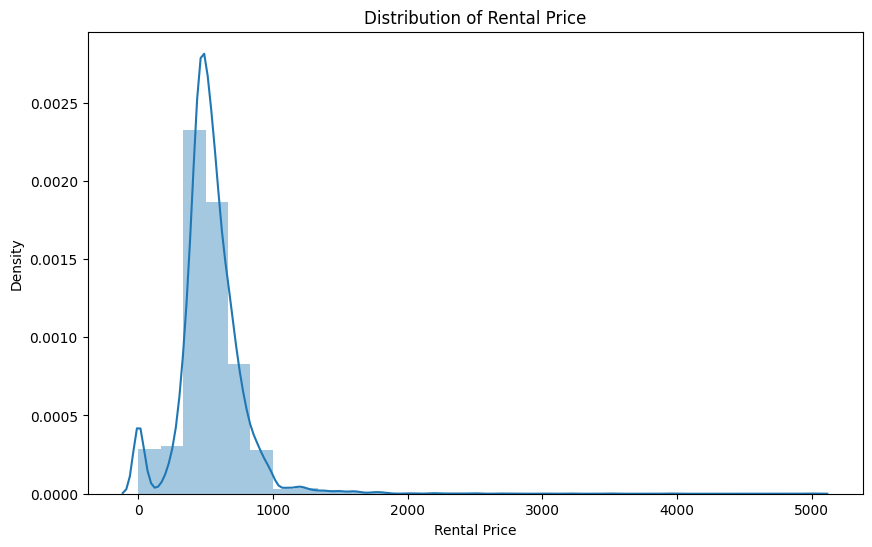

In [83]:
plt.figure(figsize=(10, 6))
sns.distplot(merged_data_2023['rental_price'], bins=30, kde=True)  # KDE为True将同时显示密度估计
plt.title('Distribution of Rental Price')
plt.xlabel('Rental Price')
plt.ylabel('Density')

plt.show()

delete invalid values

In [85]:
print("Original dataframe length:", len(merged_data_2023))

Original dataframe length: 8793


In [86]:
# select the instances with 'rental_price' > 5
merged_data_2023 = merged_data_2023[merged_data_2023['rental_price'] > 5]

print("Dataframe after removing values <= 5:", len(merged_data_2023))

Dataframe after removing values <= 5: 8442


delete the apartments which are not liveable (we think the apartment with #bedrooms or #bathrooms == 0, is not liveable)

In [87]:
print("Original dataframe length:", len(merged_data_2023))

Original dataframe length: 8442


In [88]:
# select the instances with '#bedrooms or #bathrooms != 0
merged_data_2023 = merged_data_2023[(merged_data_2023['num_bedroom'] != 0) & (merged_data_2023['num_bathroom'] != 0)]

print("Dataframe after removing rows with 0 bedrooms or bathrooms:", len(merged_data_2023))

Dataframe after removing rows with 0 bedrooms or bathrooms: 8344


remove outliers

In [89]:
# calculate Z-Score
merged_data_2023['z_score'] = (merged_data_2023['rental_price'] - merged_data_2023['rental_price'].mean()) / merged_data_2023['rental_price'].std()

# use -Score to filter
merged_data_2023 = merged_data_2023[merged_data_2023['z_score'].abs() < 3]

merged_data_2023 = merged_data_2023.drop(columns=['z_score'])


/tmp/ipykernel_8008/2127180555.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(merged_data_2023['rental_price'], bins=30, kde=True)  # KDE为True将同时显示密度估计


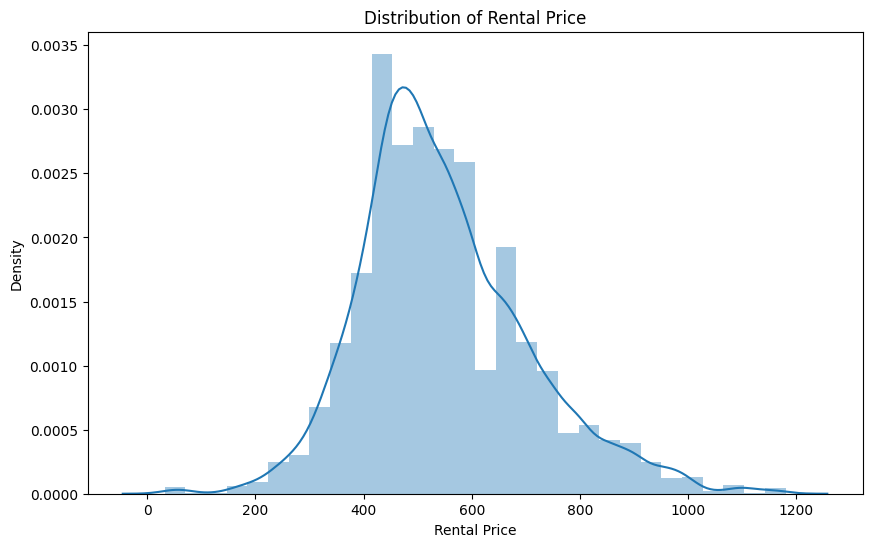

In [90]:
plt.figure(figsize=(10, 6))
sns.distplot(merged_data_2023['rental_price'], bins=30, kde=True) # set KDE True to show the density estimation
plt.title('Distribution of Rental Price')
plt.xlabel('Rental Price')
plt.ylabel('Density')

plt.show()

In [91]:
merged_data_2023

,name,coordinates,sa2_code,sa2_name,sa2_geometry,num_bedroom,num_bathroom,num_parking,pop_density,annual_pop_density_growth_rate(%),...,avg_income_growth_rate(%),offence_count,annual_offence_count_growth_rate(%),log_school_distance,log_hospital_distance,log_mall_distance,log_park_distance,log_station_distance,log_CBD_distance,rental_price
0,31 Chittagong Drive Clyde North VIC 3978,"[-38.1053122, 145.3570863]",212031556.0,Clyde North - South,POLYGON ((145.37034567475234 -38.0937851973191...,4,2,2.0,965.216952,42.856643,...,3.028540,17.333333,10.098776,0.640804,1.906040,1.239505,1.345502,2.475412,4.578730,575.0
1,50 Elmtree Crescent Clyde North VIC 3978,"[-38.0825712, 145.3561984]",212031555.0,Clyde North - North,POLYGON ((145.3346630127421 -38.07820964472685...,4,2,2.0,1746.760558,35.089903,...,3.028540,17.333333,10.098776,-0.348952,1.438925,1.052926,1.716843,1.681479,4.559835,560.0
2,7 Mortdale Lane Clyde North VIC 3978,"[-38.0961758, 145.3800644]",212031556.0,Clyde North - South,POLYGON ((145.37034567475234 -38.0937851973191...,2,2,1.0,965.216952,42.856643,...,3.028540,17.333333,10.098776,0.095820,1.847653,1.673884,1.622239,2.187960,4.586220,490.0
3,54 Walhallow Drive Clyde North VIC 3978,"[-38.1133324, 145.3457396]",212031556.0,Clyde North - South,POLYGON ((145.37034567475234 -38.0937851973191...,4,2,1.0,965.216952,42.856643,...,3.028540,17.333333,10.098776,-0.393160,1.736704,0.793410,1.183953,2.092679,4.578058,540.0
4,10 Sicily Road Clyde North VIC 3978,"[-38.1295789, 145.3642993]",212031303.0,Cranbourne South,POLYGON ((145.3254642788471 -38.12742071438774...,4,2,2.0,151.921192,6.726716,...,2.233051,31.000000,3.838837,0.799813,2.017863,1.375422,0.115940,2.315778,4.602687,520.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8797,61 Tongue Street Yarraville VIC 3013,"[-37.8131463, 144.8909053]",213031352.0,Yarraville,POLYGON ((144.85914995429522 -37.8176431203511...,2,1,0.0,1773.237842,1.100932,...,3.965740,25.000000,0.834853,-2.228826,0.374363,0.344505,1.026702,0.138021,3.826546,630.0
8798,47 Mill Avenue Yarraville VIC 3013,"[-37.8222822, 144.872198]",213031352.0,Yarraville,POLYGON ((144.85914995429522 -37.8176431203511...,4,3,2.0,1773.237842,1.100932,...,3.965740,25.000000,0.834853,-1.427862,1.122437,0.873918,1.320736,0.754430,3.823240,730.0
8799,12 Adeney Street Yarraville VIC 3013,"[-37.8163817, 144.8666543]",213031352.0,Yarraville,POLYGON ((144.85914995429522 -37.8176431203511...,3,1,2.0,1773.237842,1.100932,...,3.965740,25.000000,0.834853,-0.199202,1.025788,0.821525,1.484705,1.034856,3.805227,450.0
8800,229B Somerville Road Yarraville VIC 3013,"[-37.8124289, 144.8779569]",213031352.0,Yarraville,POLYGON ((144.85914995429522 -37.8176431203511...,1,1,0.0,1773.237842,1.100932,...,3.965740,25.000000,0.834853,-1.237029,0.623725,0.746158,1.316399,0.614537,3.810149,300.0


## 6. Build the data `merged_data_2023`

In [92]:
merged_data_2026 = merged_data_2023.copy()

assumption: We believe that only these 3 features change over time

In [93]:
merged_data_2026['pop_density'] = merged_data_2026['pop_density'] * (1 + merged_data_2026['annual_pop_density_growth_rate(%)'] / 100)**3
merged_data_2026['personal_income'] = merged_data_2026['personal_income'] * (1 + merged_data_2026['avg_income_growth_rate(%)'] / 100)**3
merged_data_2026['offence_count'] = merged_data_2026['offence_count'] * (1 + merged_data_2026['annual_offence_count_growth_rate(%)'] / 100)**3

In [94]:
merged_data_2026.head()

,name,coordinates,sa2_code,sa2_name,sa2_geometry,num_bedroom,num_bathroom,num_parking,pop_density,annual_pop_density_growth_rate(%),...,avg_income_growth_rate(%),offence_count,annual_offence_count_growth_rate(%),log_school_distance,log_hospital_distance,log_mall_distance,log_park_distance,log_station_distance,log_CBD_distance,rental_price
0,31 Chittagong Drive Clyde North VIC 3978,"[-38.1053122, 145.3570863]",212031556.0,Clyde North - South,POLYGON ((145.37034567475234 -38.0937851973191...,4,2,2.0,2814.014080,42.856643,...,3.028540,23.132872,10.098776,0.640804,1.906040,1.239505,1.345502,2.475412,4.578730,575.0
1,50 Elmtree Crescent Clyde North VIC 3978,"[-38.0825712, 145.3561984]",212031555.0,Clyde North - North,POLYGON ((145.3346630127421 -38.07820964472685...,4,2,2.0,4306.277854,35.089903,...,3.028540,23.132872,10.098776,-0.348952,1.438925,1.052926,1.716843,1.681479,4.559835,560.0
2,7 Mortdale Lane Clyde North VIC 3978,"[-38.0961758, 145.3800644]",212031556.0,Clyde North - South,POLYGON ((145.37034567475234 -38.0937851973191...,2,2,1.0,2814.014080,42.856643,...,3.028540,23.132872,10.098776,0.095820,1.847653,1.673884,1.622239,2.187960,4.586220,490.0
3,54 Walhallow Drive Clyde North VIC 3978,"[-38.1133324, 145.3457396]",212031556.0,Clyde North - South,POLYGON ((145.37034567475234 -38.0937851973191...,4,2,1.0,2814.014080,42.856643,...,3.028540,23.132872,10.098776,-0.393160,1.736704,0.793410,1.183953,2.092679,4.578058,540.0
4,10 Sicily Road Clyde North VIC 3978,"[-38.1295789, 145.3642993]",212031303.0,Cranbourne South,POLYGON ((145.3254642788471 -38.12742071438774...,4,2,2.0,184.687628,6.726716,...,2.233051,34.708923,3.838837,0.799813,2.017863,1.375422,0.115940,2.315778,4.602687,520.0


delete the label column in `merged_data_2023`.  
delete rates of change for 3 features, cuz they will not be used later

In [95]:
merged_data_2023.drop(columns=[
    'annual_pop_density_growth_rate(%)', 
    'avg_income_growth_rate(%)', 
    'annual_offence_count_growth_rate(%)'
], inplace=True)

merged_data_2026.drop(columns=[
    'rental_price', 
    'annual_pop_density_growth_rate(%)', 
    'avg_income_growth_rate(%)', 
    'annual_offence_count_growth_rate(%)'
], inplace=True)

In [96]:
merged_data_2023

,name,coordinates,sa2_code,sa2_name,sa2_geometry,num_bedroom,num_bathroom,num_parking,pop_density,personal_income,offence_count,log_school_distance,log_hospital_distance,log_mall_distance,log_park_distance,log_station_distance,log_CBD_distance,rental_price
0,31 Chittagong Drive Clyde North VIC 3978,"[-38.1053122, 145.3570863]",212031556.0,Clyde North - South,POLYGON ((145.37034567475234 -38.0937851973191...,4,2,2.0,965.216952,72706.625309,17.333333,0.640804,1.906040,1.239505,1.345502,2.475412,4.578730,575.0
1,50 Elmtree Crescent Clyde North VIC 3978,"[-38.0825712, 145.3561984]",212031555.0,Clyde North - North,POLYGON ((145.3346630127421 -38.07820964472685...,4,2,2.0,1746.760558,72706.625309,17.333333,-0.348952,1.438925,1.052926,1.716843,1.681479,4.559835,560.0
2,7 Mortdale Lane Clyde North VIC 3978,"[-38.0961758, 145.3800644]",212031556.0,Clyde North - South,POLYGON ((145.37034567475234 -38.0937851973191...,2,2,1.0,965.216952,72706.625309,17.333333,0.095820,1.847653,1.673884,1.622239,2.187960,4.586220,490.0
3,54 Walhallow Drive Clyde North VIC 3978,"[-38.1133324, 145.3457396]",212031556.0,Clyde North - South,POLYGON ((145.37034567475234 -38.0937851973191...,4,2,1.0,965.216952,72706.625309,17.333333,-0.393160,1.736704,0.793410,1.183953,2.092679,4.578058,540.0
4,10 Sicily Road Clyde North VIC 3978,"[-38.1295789, 145.3642993]",212031303.0,Cranbourne South,POLYGON ((145.3254642788471 -38.12742071438774...,4,2,2.0,151.921192,70490.898811,31.000000,0.799813,2.017863,1.375422,0.115940,2.315778,4.602687,520.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8797,61 Tongue Street Yarraville VIC 3013,"[-37.8131463, 144.8909053]",213031352.0,Yarraville,POLYGON ((144.85914995429522 -37.8176431203511...,2,1,0.0,1773.237842,100462.815420,25.000000,-2.228826,0.374363,0.344505,1.026702,0.138021,3.826546,630.0
8798,47 Mill Avenue Yarraville VIC 3013,"[-37.8222822, 144.872198]",213031352.0,Yarraville,POLYGON ((144.85914995429522 -37.8176431203511...,4,3,2.0,1773.237842,100462.815420,25.000000,-1.427862,1.122437,0.873918,1.320736,0.754430,3.823240,730.0
8799,12 Adeney Street Yarraville VIC 3013,"[-37.8163817, 144.8666543]",213031352.0,Yarraville,POLYGON ((144.85914995429522 -37.8176431203511...,3,1,2.0,1773.237842,100462.815420,25.000000,-0.199202,1.025788,0.821525,1.484705,1.034856,3.805227,450.0
8800,229B Somerville Road Yarraville VIC 3013,"[-37.8124289, 144.8779569]",213031352.0,Yarraville,POLYGON ((144.85914995429522 -37.8176431203511...,1,1,0.0,1773.237842,100462.815420,25.000000,-1.237029,0.623725,0.746158,1.316399,0.614537,3.810149,300.0


In [97]:
merged_data_2026

,name,coordinates,sa2_code,sa2_name,sa2_geometry,num_bedroom,num_bathroom,num_parking,pop_density,personal_income,offence_count,log_school_distance,log_hospital_distance,log_mall_distance,log_park_distance,log_station_distance,log_CBD_distance
0,31 Chittagong Drive Clyde North VIC 3978,"[-38.1053122, 145.3570863]",212031556.0,Clyde North - South,POLYGON ((145.37034567475234 -38.0937851973191...,4,2,2.0,2814.014080,79514.553071,23.132872,0.640804,1.906040,1.239505,1.345502,2.475412,4.578730
1,50 Elmtree Crescent Clyde North VIC 3978,"[-38.0825712, 145.3561984]",212031555.0,Clyde North - North,POLYGON ((145.3346630127421 -38.07820964472685...,4,2,2.0,4306.277854,79514.553071,23.132872,-0.348952,1.438925,1.052926,1.716843,1.681479,4.559835
2,7 Mortdale Lane Clyde North VIC 3978,"[-38.0961758, 145.3800644]",212031556.0,Clyde North - South,POLYGON ((145.37034567475234 -38.0937851973191...,2,2,1.0,2814.014080,79514.553071,23.132872,0.095820,1.847653,1.673884,1.622239,2.187960,4.586220
3,54 Walhallow Drive Clyde North VIC 3978,"[-38.1133324, 145.3457396]",212031556.0,Clyde North - South,POLYGON ((145.37034567475234 -38.0937851973191...,4,2,1.0,2814.014080,79514.553071,23.132872,-0.393160,1.736704,0.793410,1.183953,2.092679,4.578058
4,10 Sicily Road Clyde North VIC 3978,"[-38.1295789, 145.3642993]",212031303.0,Cranbourne South,POLYGON ((145.3254642788471 -38.12742071438774...,4,2,2.0,184.687628,75319.429183,34.708923,0.799813,2.017863,1.375422,0.115940,2.315778,4.602687
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8797,61 Tongue Street Yarraville VIC 3013,"[-37.8131463, 144.8909053]",213031352.0,Yarraville,POLYGON ((144.85914995429522 -37.8176431203511...,2,1,0.0,1832.451409,112895.360426,25.631382,-2.228826,0.374363,0.344505,1.026702,0.138021,3.826546
8798,47 Mill Avenue Yarraville VIC 3013,"[-37.8222822, 144.872198]",213031352.0,Yarraville,POLYGON ((144.85914995429522 -37.8176431203511...,4,3,2.0,1832.451409,112895.360426,25.631382,-1.427862,1.122437,0.873918,1.320736,0.754430,3.823240
8799,12 Adeney Street Yarraville VIC 3013,"[-37.8163817, 144.8666543]",213031352.0,Yarraville,POLYGON ((144.85914995429522 -37.8176431203511...,3,1,2.0,1832.451409,112895.360426,25.631382,-0.199202,1.025788,0.821525,1.484705,1.034856,3.805227
8800,229B Somerville Road Yarraville VIC 3013,"[-37.8124289, 144.8779569]",213031352.0,Yarraville,POLYGON ((144.85914995429522 -37.8176431203511...,1,1,0.0,1832.451409,112895.360426,25.631382,-1.237029,0.623725,0.746158,1.316399,0.614537,3.810149


store `merged_data_2023` & `merged_data_2026`

In [98]:
output_directory = '../data/curated/final_data/merged_data_2023.csv'
merged_data_2023.to_csv(output_directory, index=False)

In [99]:
output_directory = '../data/curated/final_data/merged_data_2026.csv'
merged_data_2026.to_csv(output_directory, index=False)